# Predikcija kategorije proizvoda na osnovu naslova

## Uvod

Cilj ovog projekta je razvoj modela mašinskog učenja koji automatski predviđa kategoriju proizvoda na osnovu njegovog naziva (`Product Title`).

U skladu sa zadatkom, sveska prikazuje kompletan tok rada:
- učitavanje i analizu podataka,
- čišćenje i pripremu skupa,
- inženjering karakteristika,
- treniranje i poređenje najmanje dva modela,
- evaluaciju pomoću accuracy, classification report i confusion matrix,
- čuvanje finalnog modela u `.pkl` formatu,
- testiranje na zadatim primjerima iz zadatka.


In [1]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline, FeatureUnion
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import ComplementNB
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.base import BaseEstimator, TransformerMixin
from scipy.sparse import csr_matrix

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 200)

## 1. Učitavanje podataka

In [2]:
df = pd.read_csv("../data/products.csv")

# Uklanjanje viška razmaka iz naziva kolona
df.columns = df.columns.str.strip()

print("Shape dataseta:", df.shape)
print("\nKolone:")
print(df.columns.tolist())

df.head()

Shape dataseta: (35311, 8)

Kolone:
['product ID', 'Product Title', 'Merchant ID', 'Category Label', '_Product Code', 'Number_of_Views', 'Merchant Rating', 'Listing Date']


,product ID,Product Title,Merchant ID,Category Label,_Product Code,Number_of_Views,Merchant Rating,Listing Date
0,1,apple iphone 8 plus 64gb silver,1,Mobile Phones,QA-2276-XC,860.0,2.5,5/10/2024
1,2,apple iphone 8 plus 64 gb spacegrau,2,Mobile Phones,KA-2501-QO,3772.0,4.8,12/31/2024
2,3,apple mq8n2b/a iphone 8 plus 64gb 5.5 12mp sim free smartphone in gold,3,Mobile Phones,FP-8086-IE,3092.0,3.9,11/10/2024
3,4,apple iphone 8 plus 64gb space grey,4,Mobile Phones,YI-0086-US,466.0,3.4,5/2/2022
4,5,apple iphone 8 plus gold 5.5 64gb 4g unlocked sim free,5,Mobile Phones,NZ-3586-WP,4426.0,1.6,4/12/2023


## 2. Osnovna analiza podataka (EDA)

In [3]:
df.isnull().sum().sort_values(ascending=False)

Product Title      172
Merchant Rating    170
_Product Code       95
Listing Date        59
Category Label      44
Number_of_Views     14
Merchant ID          0
product ID           0
dtype: int64

In [4]:
df["Category Label"].value_counts(dropna=False)

Category Label
Fridge Freezers     5495
Washing Machines    4036
Mobile Phones       4020
CPUs                3771
TVs                 3564
Fridges             3457
Dishwashers         3418
Digital Cameras     2696
Microwaves          2338
Freezers            2210
fridge               123
CPU                   84
Mobile Phone          55
NaN                   44
Name: count, dtype: int64

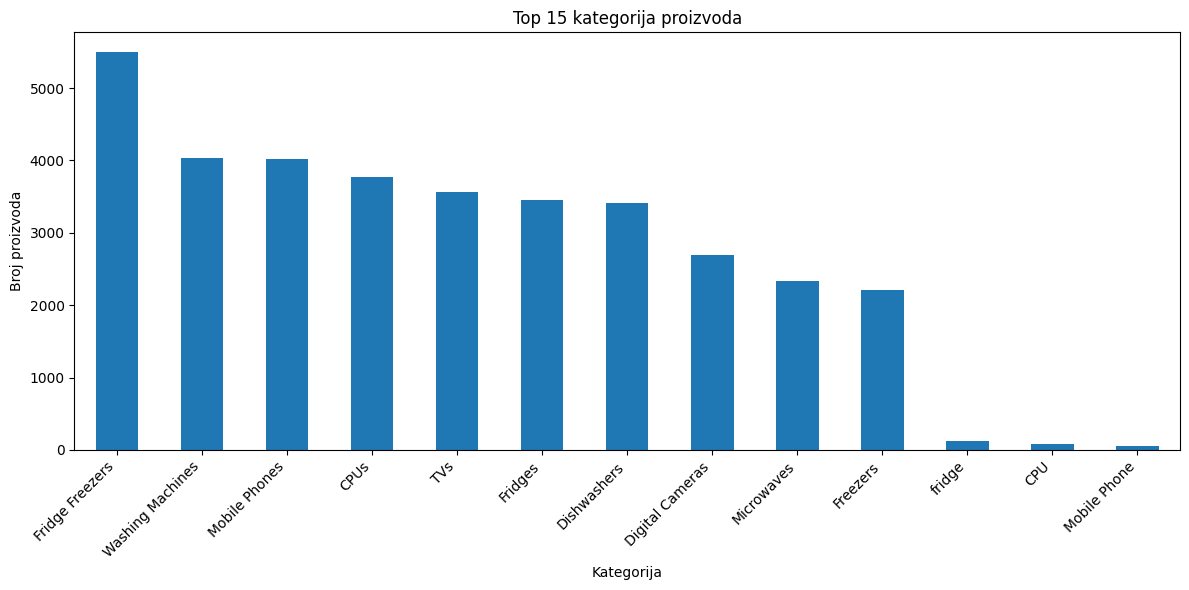

In [5]:
df["Category Label"].value_counts().head(15).plot(kind="bar", figsize=(12, 6))
plt.title("Top 15 kategorija proizvoda")
plt.xlabel("Kategorija")
plt.ylabel("Broj proizvoda")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 3. Čišćenje podataka

U datasetu postoje:
- nedostajuće vrijednosti u kolonama `Product Title` i `Category Label`,
- nekonzistentne oznake kategorija (`fridge` / `Fridges`, `CPU` / `CPUs`, `Mobile Phone` / `Mobile Phones`).

Zato standardizujemo labele i čistimo tekstualnu kolonu koja se koristi za modeliranje.


In [6]:
label_map = {
    "fridge": "Fridges",
    "CPU": "CPUs",
    "Mobile Phone": "Mobile Phones"
}

df["Category Label"] = df["Category Label"].replace(label_map)

df = df.dropna(subset=["Product Title", "Category Label"]).copy()
df["Product Title"] = df["Product Title"].astype(str).str.strip().str.lower()
df = df[df["Product Title"] != ""].copy()

print("Shape nakon čišćenja:", df.shape)
print("\nBroj kategorija nakon standardizacije:", df["Category Label"].nunique())
df["Category Label"].value_counts()

Shape nakon čišćenja: (35096, 8)

Broj kategorija nakon standardizacije: 10


Category Label
Fridge Freezers     5470
Mobile Phones       4057
Washing Machines    4015
CPUs                3831
Fridges             3559
TVs                 3541
Dishwashers         3405
Digital Cameras     2689
Microwaves          2328
Freezers            2201
Name: count, dtype: int64

## 4. Inženjering karakteristika

Pored TF-IDF prikaza teksta, dodaćemo i ručno izvedene karakteristike iz naslova proizvoda:
- broj karaktera,
- broj riječi,
- broj cifara,
- da li naslov sadrži cifre,
- broj specijalnih znakova,
- dužina najduže riječi.

Ove dodatne informacije mogu pomoći modelu da bolje razlikuje kategorije.


In [7]:
class TitleMetaFeatures(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        s = pd.Series(X).fillna("").astype(str)

        features = pd.DataFrame({
            "char_len": s.str.len(),
            "word_count": s.str.split().str.len(),
            "digit_count": s.str.count(r"\d"),
            "has_digit": s.str.contains(r"\d").astype(int),
            "special_count": s.str.count(r"[^A-Za-z0-9\s]"),
            "longest_word_len": s.apply(lambda x: max([len(word) for word in x.split()] or [0]))
        })

        return csr_matrix(features.values)

In [8]:
sample_titles = df["Product Title"].head(5)
TitleMetaFeatures().fit_transform(sample_titles).toarray()

array([[31,  6,  3,  1,  0,  6],
       [35,  7,  3,  1,  0,  9],
       [70, 13,  9,  1,  2, 10],
       [35,  7,  3,  1,  0,  6],
       [54, 11,  6,  1,  1,  8]])

## 5. Priprema ulaznih i ciljnih podataka

In [9]:
X = df["Product Title"]
y = df["Category Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (28076,)
Test shape: (7020,)


## 6. Definisanje pipeline-a i modela

In [10]:
def build_pipeline(classifier):
    return Pipeline([
        ("features", FeatureUnion([
            ("tfidf", TfidfVectorizer(
                ngram_range=(1, 2),
                min_df=3,
                max_df=0.98,
                sublinear_tf=True
            )),
            ("meta", TitleMetaFeatures())
        ])),
        ("classifier", classifier)
    ])

In [11]:
models = {
    "ComplementNB": build_pipeline(ComplementNB(alpha=0.5)),
    "SGDClassifier": build_pipeline(
        SGDClassifier(loss="hinge", random_state=42, max_iter=1000, tol=1e-3)
    )
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)

    results.append({
        "Model": name,
        "Accuracy": acc
    })

results_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)
results_df

,Model,Accuracy
0,ComplementNB,0.955128
1,SGDClassifier,0.848718


## 7. Izbor i evaluacija najboljeg modela

In [12]:
best_model_name = results_df.iloc[0]["Model"]
best_model = models[best_model_name]

best_model.fit(X_train, y_train)
best_preds = best_model.predict(X_test)

print("Najbolji model:", best_model_name)
print("Accuracy:", accuracy_score(y_test, best_preds))

Najbolji model: ComplementNB
Accuracy: 0.9551282051282052


In [13]:
print(classification_report(y_test, best_preds))

                  precision    recall  f1-score   support

            CPUs       0.98      1.00      0.99       766
 Digital Cameras       0.99      1.00      0.99       538
     Dishwashers       0.89      0.98      0.93       681
        Freezers       0.99      0.85      0.91       440
 Fridge Freezers       0.91      0.94      0.93      1094
         Fridges       0.91      0.88      0.89       712
      Microwaves       0.98      0.98      0.98       466
   Mobile Phones       1.00      0.98      0.99       812
             TVs       0.98      0.98      0.98       708
Washing Machines       0.97      0.95      0.96       803

        accuracy                           0.96      7020
       macro avg       0.96      0.95      0.96      7020
    weighted avg       0.96      0.96      0.95      7020



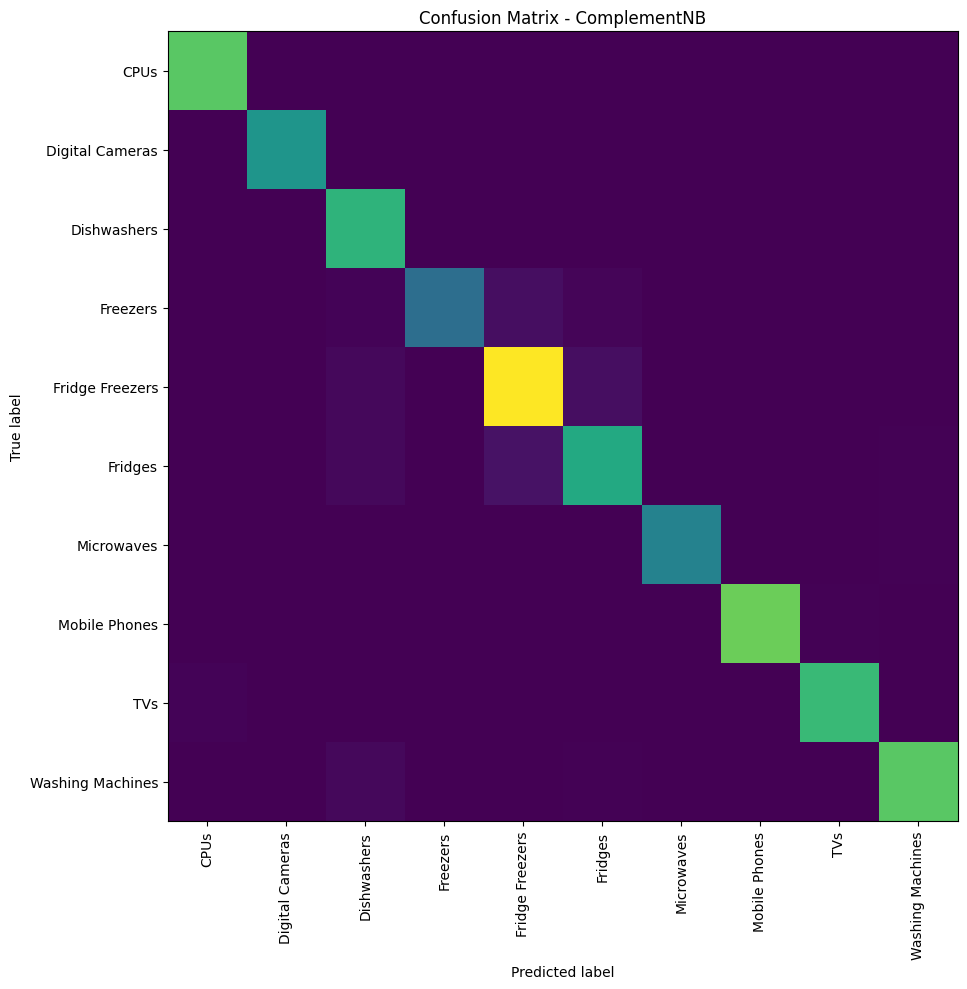

In [14]:
labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_preds, labels=labels)

plt.figure(figsize=(12, 10))
plt.imshow(cm)
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.xticks(range(len(labels)), labels, rotation=90)
plt.yticks(range(len(labels)), labels)
plt.tight_layout()
plt.show()

## 8. Treniranje finalnog modela na kompletnom skupu i čuvanje

In [15]:
final_model = models[best_model_name]
final_model.fit(X, y)

os.makedirs("../models", exist_ok=True)
joblib.dump(final_model, "../models/product_category_model.pkl")

print("Model je uspješno sačuvan u ../models/product_category_model.pkl")

Model je uspješno sačuvan u ../models/product_category_model.pkl


## 9. Testiranje na zadatim primjerima

In [16]:
test_titles = [
    "iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",
    "olympus e m10 mark iii geh use silber",
    "kenwood k20mss15 solo",
    "bosch wap28390gb 8kg 1400 spin",
    "bosch serie 4 kgv39vl31g",
    "smeg sbs8004po"
]

predictions = final_model.predict(test_titles)

pd.DataFrame({
    "Product Title": test_titles,
    "Predicted Category": predictions
})

,Product Title,Predicted Category
0,"iphone 7 32gb gold,4,3,Apple iPhone 7 32GB",Mobile Phones
1,olympus e m10 mark iii geh use silber,Digital Cameras
2,kenwood k20mss15 solo,Microwaves
3,bosch wap28390gb 8kg 1400 spin,Washing Machines
4,bosch serie 4 kgv39vl31g,Fridge Freezers
5,smeg sbs8004po,Dishwashers


## 10. Zaključak

U ovom projektu razvijen je model za automatsku klasifikaciju proizvoda na osnovu naslova proizvoda.

Prikazan je kompletan tok rada:
- analiza i priprema podataka,
- standardizacija ciljnih kategorija,
- inženjering dodatnih karakteristika,
- treniranje i poređenje dva modela,
- evaluacija pomoću accuracy, classification report i confusion matrix,
- čuvanje finalnog modela za dalju upotrebu.

Finalni model je spreman za korišćenje kroz poseban skript `predict_category.py`.
